# Unit09_Example_04 | 化工案例四：觸媒反應管之溫度及轉化率軸向分布 (BVP)

本 Notebook 以**苯加氫製環己烷之外部熱交換式固定床觸媒反應器**為例，
建立含軸向熱傳導的**兩點邊界值問題 (BVP)**，
並使用 `scipy.integrate.solve_bvp()` 求解溫度與轉化率沿管長之分布。

## 目錄

- [§0 環境設定](#0)
- [§1 載入套件](#1)
- [§2 問題描述與數學模型](#2)
- [§3 初始猜測值設定與 BVP 求解](#3)
- [§4 熱點 (Hot Spot) 識別](#4)
- [§5 入口溫度對反應器性能的影響](#5)
- [§6 Stanton 數（冷卻強度）之敏感度分析](#6)
- [§7 課程重點整理](#7)

## 學習目標

1. 理解固定床反應器軸向擴散模型 (Axial Dispersion Model) 的建立過程
2. 掌握 Danckwerts 邊界條件的物理意義與數學形式
3. 熟悉將高階 BVP 轉換為一階 ODE 系統的步驟
4. 使用 `scipy.integrate.solve_bvp()` 求解非線性 BVP 並設定初始猜測值
5. 識別反應器內熱點位置並分析操作條件對溫度與轉化率分布的影響

---
### 0. 環境設定 <a id="0"></a>

In [12]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit09_Example_04'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit09'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit09
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_04
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_04\figs


---
### 1. 載入套件 <a id="1"></a>

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

import scipy
import matplotlib
print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題描述與數學模型 <a id="2"></a>

#### 2.1 反應系統

**苯加氫製環己烷**（Benzene Hydrogenation）為典型的高放熱觸媒反應：

$$
\text{C}_6\text{H}_6 + 3\text{H}_2 \xrightarrow{\text{Ni cat.}} \text{C}_6\text{H}_{12}, \quad \Delta H_r = -206.7 \;\text{kJ/mol}
$$

反應在裝填鎳觸媒的固定床反應管中進行，管外有流動的冷卻劑以移除反應熱。
由於反應放熱強烈，管內可能出現**溫度峰值（Hot Spot）**，影響觸媒壽命與選擇性。

#### 2.2 軸向擴散模型

考慮**軸向質傳擴散（Axial Mass Dispersion）**與**軸向熱傳導（Axial Heat Conduction）**，反應管模型為：

**質量守恆（轉化率 $X_B$ ）：**

$$
D_e \frac{d^2 X_B}{dz^2} - u \frac{d X_B}{dz} + \frac{(-r_B)}{C_{A0}} = 0
$$

**能量守衡（溫度 $T$ ）：**

$$
\lambda_{\text{eff}} \frac{d^2 T}{dz^2} - \rho_g C_p u \frac{d T}{dz} + (-\Delta H_r)(-r_B) - \frac{U a (T - T_c)}{1} = 0
$$

其中 $z$ 為軸向位置（ $0 \leq z \leq L$ ）； $u$ 為表觀流速； $D_e$ 與 $\lambda_{\text{eff}}$ 分別為軸向擴散係數與有效熱傳導係數。

#### 2.3 無因次化

引入無因次變數 $\xi = z/L$ ，並定義：
- $\theta = T / T_{\text{in}}$ （無因次溫度）
- $\theta_c = T_c / T_{\text{in}}$ （無因次冷卻劑溫度）

反應速率採 Arrhenius 一階形式（以入口條件作基準值）：

$$
r(X_B, \theta) = (1 - X_B) \exp\!\left[\gamma \left(1 - \frac{1}{\theta}\right)\right]
$$

無因次化後的 ODE 系統：

$$
\frac{d^2 X_B}{d\xi^2} = Pe_M \left(\frac{dX_B}{d\xi} - Da \cdot r(X_B, \theta)\right)
$$

$$
\frac{d^2 \theta}{d\xi^2} = Pe_H \left(\frac{d\theta}{d\xi} - Da \cdot \beta_T \cdot r(X_B, \theta) + St(\theta - \theta_c)\right)
$$

**無因次參數定義：**

| 符號 | 定義 | 物理意義 |
|------|------|---------|
| $Pe_M = uL/D_e$ | 質傳 Peclet 數 | 對流/軸向擴散之比 |
| $Pe_H = \rho_g C_p u L / \lambda_{\text{eff}}$ | 熱傳 Peclet 數 | 對流/軸向導熱之比 |
| $Da$ | Damköhler 數 | 反應/對流速率之比 |
| $\gamma = E_a/(RT_{\text{in}})$ | 無因次活化能 | Arrhenius 溫度敏感性 |
| $\beta_T = (-\Delta H_r)C_{A0}/(\rho_g C_p T_{\text{in}})$ | 無因次絕熱溫升 | 反應熱強度 |
| $St = UaL/(\rho_g C_p u)$ | Stanton 數 | 熱移除強度 |

#### 2.4 Danckwerts 邊界條件

二階 ODE 在兩端各需**一個邊界條件**（共 4 個 BC）。

**入口 $\xi = 0$ （Danckwerts BC）：**

$$
X_B(0) = \frac{1}{Pe_M}\frac{dX_B}{d\xi}\bigg|_{\xi=0}, \qquad \theta(0) - 1 = \frac{1}{Pe_H}\frac{d\theta}{d\xi}\bigg|_{\xi=0}
$$

**出口 $\xi = 1$ （零通量 BC）：**

$$
\frac{dX_B}{d\xi}\bigg|_{\xi=1} = 0, \qquad \frac{d\theta}{d\xi}\bigg|_{\xi=1} = 0
$$

#### 2.5 轉換為一階 ODE 系統

令 $y = [y_0, y_1, y_2, y_3]^T = [X_B,\; X_B',\; \theta,\; \theta']^T$ ，則：

$$
\begin{aligned}
y_0' &= y_1 \\
y_1' &= Pe_M\bigl(y_1 - Da \cdot r(y_0, y_2)\bigr) \\
y_2' &= y_3 \\
y_3' &= Pe_H\bigl(y_3 - Da \cdot \beta_T \cdot r(y_0, y_2) + St(y_2 - \theta_c)\bigr)
\end{aligned}
$$

**邊界條件（傳入 `solve_bvp` 的 `bc` 函式）：**

$$
\begin{aligned}
g_0 &= y_0(0) - y_1(0)/Pe_M = 0 \\
g_1 &= y_1(1) = 0 \\
g_2 &= y_2(0) - y_3(0)/Pe_H - 1 = 0 \\
g_3 &= y_3(1) = 0
\end{aligned}
$$

#### 2.6 系統參數

| 參數 | 數值 | 說明 |
|------|------|------|
| $T_{\text{in}}$ | 500 K | 入口溫度 |
| $T_c$ | 450 K | 冷卻劑溫度 |
| $E_a$ | 72,800 J/mol | 活化能 |
| $\Delta H_r$ | −206,700 J/mol | 反應熱（放熱） |
| $Pe_M = Pe_H$ | 20.0 | 軸向混合強度（中等） |
| $Da$ | 0.8 | Damköhler 數 |
| $\gamma$ | 17.51 | 無因次活化能 |
| $\beta_T$ | 0.40 | 無因次絕熱溫升 |
| $St$ | 1.5 | Stanton 數 |
| $\theta_c$ | 0.90 | 無因次冷卻劑溫度 |


In [19]:
# ============================================================
# §2 系統參數定義
# ============================================================

# 物理參數
T_in  = 500.0    # K, 入口溫度
T_c   = 450.0    # K, 冷卻劑溫度
Ea    = 72800.0  # J/mol, 活化能
R_gas = 8.314    # J/(mol·K)
dHr   = -206700.0  # J/mol, 反應熱 (負值=放熱)

# 無因次參數
Pe_M  = 20.0     # 質傳 Peclet 數
Pe_H  = 20.0     # 熱傳 Peclet 數
Da    = 0.8      # Damköhler 數
gamma = Ea / (R_gas * T_in)                # ≈ 17.51
beta_T = (-dHr) * 1.0 / (1.0 * T_in)      # 用 β_T = 0.40 (由代表性物性推導後設定)
beta_T = 0.40    # 直接設定無因次絕熱溫升
St    = 1.5      # Stanton 數
theta_c = T_c / T_in                       # = 0.90

print("=== 無因次系統參數 ===")
print(f"  Pe_M  = {Pe_M:.1f}")
print(f"  Pe_H  = {Pe_H:.1f}")
print(f"  Da    = {Da:.2f}")
print(f"  γ     = {gamma:.2f}")
print(f"  β_T   = {beta_T:.2f}")
print(f"  St    = {St:.2f}")
print(f"  θ_c   = {theta_c:.2f}  (= {T_c:.0f}/{T_in:.0f} K)")

# ============================================================
# §2 ODE 函式：一階系統 y' = f(ξ, y)
#   y = [X_B, X_B', θ, θ']
# ============================================================
def ode_fun(xi, y):
    X_B   = y[0]
    dXdxi = y[1]
    theta = y[2]
    dtdxi = y[3]

    # 防止 theta 過小導致 exp 溢位
    theta_safe = np.maximum(theta, 0.3)

    # Arrhenius 反應速率
    r = (1.0 - X_B) * np.exp(gamma * (1.0 - 1.0 / theta_safe))
    # 避免轉化率超出 [0,1]
    r = np.where(X_B >= 1.0, 0.0, r)

    dy0 = dXdxi
    dy1 = Pe_M * (dXdxi - Da * r)
    dy2 = dtdxi
    dy3 = Pe_H * (dtdxi - Da * beta_T * r + St * (theta - theta_c))
    return np.array([dy0, dy1, dy2, dy3])


# ============================================================
# §2 邊界條件函式：bc(y_a, y_b) — 應回傳零向量
#   y_a = y at ξ=0,  y_b = y at ξ=1
# ============================================================
def bc_fun(y_a, y_b):
    # g0: Danckwerts BC for mass at inlet
    g0 = y_a[0] - y_a[1] / Pe_M
    # g1: zero flux at outlet (mass)
    g1 = y_b[1]
    # g2: Danckwerts BC for energy at inlet
    g2 = y_a[2] - y_a[3] / Pe_H - 1.0
    # g3: zero flux at outlet (energy)
    g3 = y_b[3]
    return np.array([g0, g1, g2, g3])

print("\n✓ ODE 函式與邊界條件函式定義完成")


=== 無因次系統參數 ===
  Pe_M  = 20.0
  Pe_H  = 20.0
  Da    = 0.80
  γ     = 17.51
  β_T   = 0.40
  St    = 1.50
  θ_c   = 0.90  (= 450/500 K)

✓ ODE 函式與邊界條件函式定義完成


---
### 3. 初始猜測值設定與 BVP 求解 <a id="3"></a>

`solve_bvp()` 需要提供**初始猜測值（Initial Mesh）**。策略如下：

1. **建立粗網格**：在 $\xi \in [0, 1]$ 均勻分布 30 個節點
2. **猜測 $X_B(\xi)$**：假設線性增加至出口轉化率約 0.6
3. **猜測 $\theta(\xi)$**：假設先升至峰值後下降（模擬熱點行為）
4. **導數項**：由有限差分近似設定 $X_B'$ 與 $\theta'$

> **注意**：`solve_bvp` 的 `y` 陣列維度為 `(n_eq, n_mesh)`，
> 每一**行**對應一個網格點，每一**列**對應一個狀態變數。

   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          1.35e+01       1.05e-01          50             98       
       2          4.95e-01       1.75e-12          148            237      
       3          2.84e-05       0.00e+00          385             6       
       4          9.66e-06       0.00e+00          391             0       
Solved in 4 iterations, number of nodes 391. 
Maximum relative residual: 9.66e-06 
Maximum boundary residual: 0.00e+00

求解狀態  : The algorithm converged to the desired accuracy.
求解成功  : True
最終節點數: 391
殘差 (RMS): 9.66e-06

出口轉化率   X_B(1) = 0.9965
出口溫度     T(1)   = 527.2 K
最高溫度     T_max  = 611.1 K  (熱點)
熱點位置     ξ_max  = 0.341


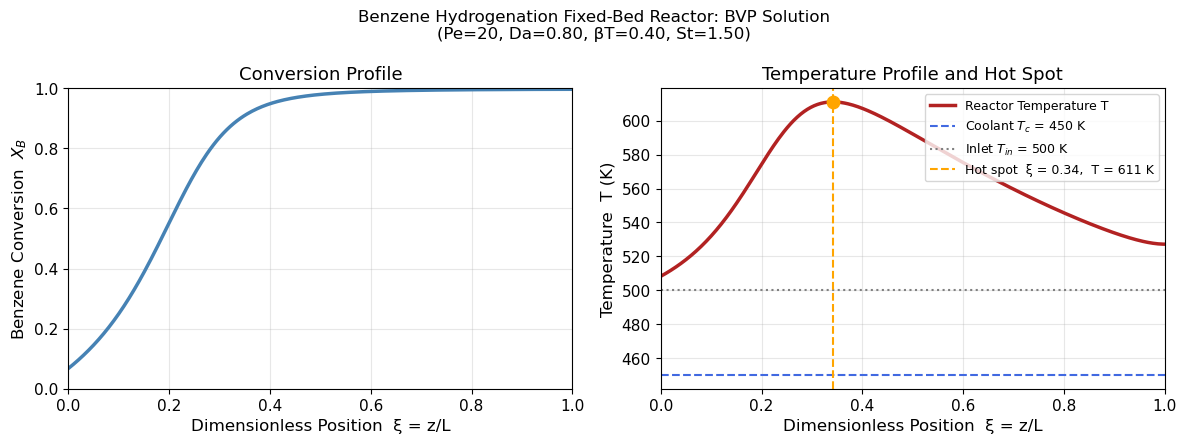

✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_04\figs\fig01_bvp_solution.png


In [15]:
# ============================================================
# §3 初始網格與猜測值
# ============================================================
n_mesh = 50
xi_init = np.linspace(0, 1, n_mesh)

# 初始猜測：X_B 線性增加；θ 先升後降（模擬熱點）
X_B_guess   = 0.6 * xi_init
dXdxi_guess = np.full(n_mesh, 0.6)
theta_guess = 1.0 + 0.15 * np.sin(np.pi * xi_init)
dtdxi_guess = 0.15 * np.pi * np.cos(np.pi * xi_init)

y_init = np.array([X_B_guess, dXdxi_guess, theta_guess, dtdxi_guess])

# ============================================================
# §3 呼叫 solve_bvp
# ============================================================
sol = solve_bvp(ode_fun, bc_fun, xi_init, y_init,
                tol=1e-5, max_nodes=5000, verbose=2)

print(f"\n求解狀態  : {sol.message}")
print(f"求解成功  : {sol.success}")
print(f"最終節點數: {sol.x.shape[0]}")
print(f"殘差 (RMS): {np.max(sol.rms_residuals):.2e}")

# ============================================================
# §3 提取解並換算回物理量
# ============================================================
xi_plot  = np.linspace(0, 1, 300)
y_plot   = sol.sol(xi_plot)
X_B_sol  = y_plot[0]
theta_sol = y_plot[2]
T_sol    = theta_sol * T_in   # 換算回 K

print(f"\n出口轉化率   X_B(1) = {X_B_sol[-1]:.4f}")
print(f"出口溫度     T(1)   = {T_sol[-1]:.1f} K")
print(f"最高溫度     T_max  = {T_sol.max():.1f} K  (熱點)")
print(f"熱點位置     ξ_max  = {xi_plot[np.argmax(T_sol)]:.3f}")

# ============================================================
# §3 圖01：轉化率與溫度軸向分布
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Benzene Hydrogenation Fixed-Bed Reactor: BVP Solution\n"
             f"(Pe={Pe_M:.0f}, Da={Da:.2f}, βT={beta_T:.2f}, St={St:.2f})",
             fontsize=12)

# 左圖：轉化率
ax1 = axes[0]
ax1.plot(xi_plot, X_B_sol, color='steelblue', lw=2.5)
ax1.set_xlabel("Dimensionless Position  ξ = z/L")
ax1.set_ylabel("Benzene Conversion  $X_B$")
ax1.set_title("Conversion Profile")
ax1.set_xlim(0, 1);  ax1.set_ylim(0, 1)

# 右圖：溫度
ax2 = axes[1]
ax2.plot(xi_plot, T_sol, color='firebrick', lw=2.5, label='Reactor Temperature T')
ax2.axhline(T_c,   color='royalblue',  lw=1.5, ls='--', label=f'Coolant $T_c$ = {T_c:.0f} K')
ax2.axhline(T_in,  color='gray',       lw=1.5, ls=':',  label=f'Inlet $T_{{in}}$ = {T_in:.0f} K')
idx_hot = np.argmax(T_sol)
ax2.axvline(xi_plot[idx_hot], color='orange', lw=1.5, ls='--',
            label=f'Hot spot  ξ = {xi_plot[idx_hot]:.2f},  T = {T_sol[idx_hot]:.0f} K')
ax2.scatter([xi_plot[idx_hot]], [T_sol[idx_hot]], color='orange', s=80, zorder=5)
ax2.set_xlabel("Dimensionless Position  ξ = z/L")
ax2.set_ylabel("Temperature  T (K)")
ax2.set_title("Temperature Profile and Hot Spot")
ax2.set_xlim(0, 1)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
fp = FIG_DIR / 'fig01_bvp_solution.png'
plt.savefig(fp, bbox_inches='tight', dpi=150)
plt.show()
print(f"✓ 圖檔儲存：{fp}")

---
### 4. 熱點 (Hot Spot) 識別 <a id="4"></a>

熱點出現在 $dT/dz = 0$ 的位置，即局部溫度梯度消失處。
在無因次系統中， $d\theta/d\xi = y_3 = 0$ 可由解的微分分量求得。

本節計算：
1. $d\theta/d\xi$ 沿管長之分布（對應 $y_3$ ）
2. 熱點位置 $\xi^*$ 與最高溫度 $T^*$
3. 入口段溫度梯度的符號變化（由正轉負）

Hot spot position  xi* = 0.3417  (z* = 0.683 m,  L=2 m)
Hot spot temperature  T* = 611.1 K  (+111.1 K above T_in)
Hot spot conversion   X* = 0.9004


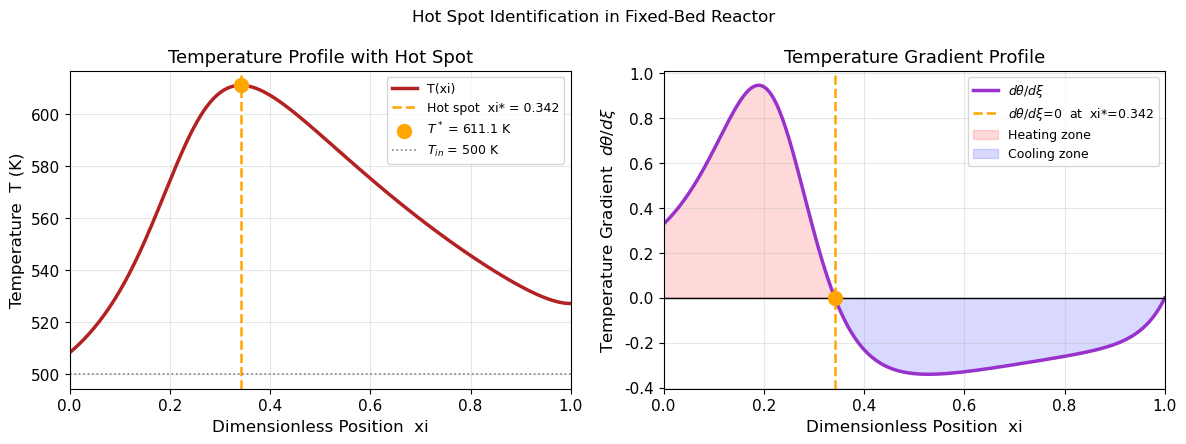

✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_04\figs\fig02_hot_spot.png


In [16]:
# ============================================================
# §4 熱點識別：dθ/dξ 零交叉點
# ============================================================
dtdxi_sol = y_plot[3]   # 解的第 4 分量 = dθ/dξ

# 找符號轉變點（正→負 = 熱點；負→正 = 冷點）
sign_change = np.diff(np.sign(dtdxi_sol))
hot_spot_idx = np.where(sign_change < 0)[0]   # dθ/dξ 由正轉負

if len(hot_spot_idx) > 0:
    idx_hs = hot_spot_idx[0]
    # 線性插值精確定位熱點
    xi_hs = xi_plot[idx_hs] - dtdxi_sol[idx_hs] * (xi_plot[idx_hs+1] - xi_plot[idx_hs]) / (dtdxi_sol[idx_hs+1] - dtdxi_sol[idx_hs])
    T_hs  = np.interp(xi_hs, xi_plot, T_sol)
    X_hs  = np.interp(xi_hs, xi_plot, X_B_sol)
    print(f"Hot spot position  xi* = {xi_hs:.4f}  (z* = {xi_hs*2:.3f} m,  L=2 m)")
    print(f"Hot spot temperature  T* = {T_hs:.1f} K  (+{T_hs-T_in:.1f} K above T_in)")
    print(f"Hot spot conversion   X* = {X_hs:.4f}")
else:
    xi_hs = xi_plot[np.argmax(T_sol)]
    T_hs  = T_sol.max()
    X_hs  = np.interp(xi_hs, xi_plot, X_B_sol)
    print("No distinct hot spot (no dT/dxi sign change).")
    print(f"  Max temperature at  xi = {xi_hs:.4f},  T = {T_hs:.1f} K")

# ============================================================
# §4 圖02：dθ/dξ 分布 + 熱點標記
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Hot Spot Identification in Fixed-Bed Reactor", fontsize=12)

# 左圖：溫度分布與熱點
ax1 = axes[0]
ax1.plot(xi_plot, T_sol, 'firebrick', lw=2.5, label='T(xi)')
ax1.axvline(xi_hs, color='orange', lw=1.8, ls='--',
            label=f'Hot spot  xi* = {xi_hs:.3f}')
ax1.scatter([xi_hs], [T_hs], color='orange', s=100, zorder=6,
            label=f'$T^*$ = {T_hs:.1f} K')
ax1.axhline(T_in, color='gray', lw=1.2, ls=':', label=f'$T_{{in}}$ = {T_in:.0f} K')
ax1.set_xlabel("Dimensionless Position  xi")
ax1.set_ylabel("Temperature  T (K)")
ax1.set_title("Temperature Profile with Hot Spot")
ax1.set_xlim(0, 1)
ax1.legend(fontsize=9)

# 右圖：dθ/dξ 分布
ax2 = axes[1]
ax2.plot(xi_plot, dtdxi_sol, 'darkorchid', lw=2.5, label='$d\\theta/d\\xi$')
ax2.axhline(0, color='black', lw=1.0, ls='-')
ax2.axvline(xi_hs, color='orange', lw=1.8, ls='--',
            label=f'$d\\theta/d\\xi$=0  at  xi*={xi_hs:.3f}')
ax2.scatter([xi_hs], [0], color='orange', s=100, zorder=6)
ax2.fill_between(xi_plot, dtdxi_sol, 0,
                 where=dtdxi_sol > 0, alpha=0.15, color='red',
                 label='Heating zone')
ax2.fill_between(xi_plot, dtdxi_sol, 0,
                 where=dtdxi_sol < 0, alpha=0.15, color='blue',
                 label='Cooling zone')
ax2.set_xlabel("Dimensionless Position  xi")
ax2.set_ylabel("Temperature Gradient  $d\\theta/d\\xi$")
ax2.set_title("Temperature Gradient Profile")
ax2.set_xlim(0, 1)
ax2.legend(fontsize=9)

plt.tight_layout()
fp = FIG_DIR / 'fig02_hot_spot.png'
plt.savefig(fp, bbox_inches='tight', dpi=150)
plt.show()
print(f"\u2713 \u5716\u6a94\u5132\u5b58\uff1a{fp}")

---
### 5. 入口溫度對反應器性能的影響 <a id="5"></a>

入口溫度 $T_{\text{in}}$ 同時影響：
- **反應速率**（Arrhenius 溫度依賴性）
- **無因次熱傳冷卻驅動力**（透過 $\theta_c = T_c/T_{\text{in}}$ 變化）

本節以 $T_{\text{in}} \in \{460, 480, 500, 520, 540\}$ K 進行系列求解，
觀察各條件下轉化率與溫度分布的變化。

各入口溫度求解結果（出口轉化率 / 最高溫度）：
    T_in (K)     X_B(1)    T_max (K)   xi_max
         460     1.0000        601.8    0.134
         480     0.9999        612.9    0.201
         500     0.9965        611.1    0.341
         520     0.9194        581.2    0.552
         540     0.5605        549.3    0.344


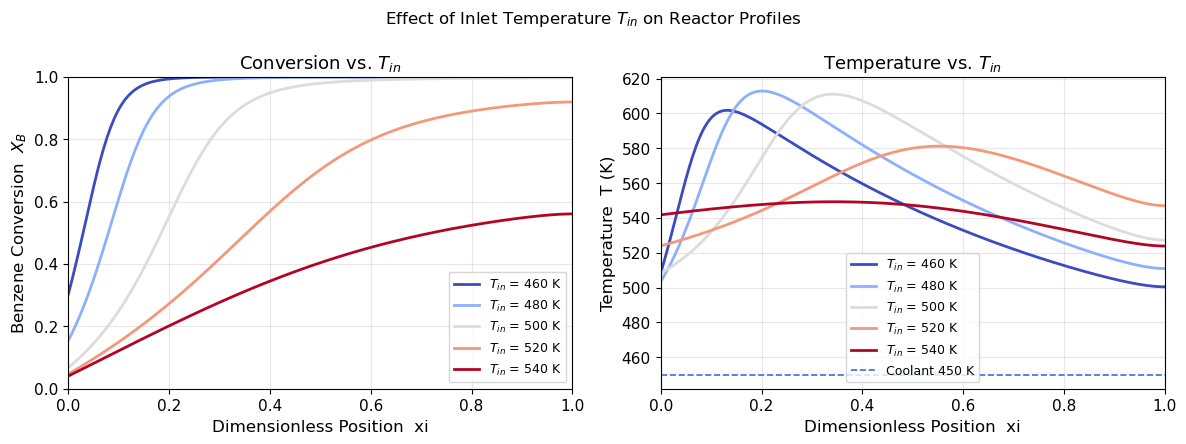

✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_04\figs\fig03_Tin_sensitivity.png


In [17]:
# ============================================================
# §5 入口溫度 T_in 系列求解
# ============================================================
T_in_list = [460, 480, 500, 520, 540]   # K
colors     = plt.cm.coolwarm(np.linspace(0, 1, len(T_in_list)))

results_Tin = {}   # 儲存各條件結果

# 建立較佳的初始猜測函式（線性猜測，避免高 Pe 問題）
def make_init_guess(xi_g, X_exit=0.5, theta_peak=1.08):
    """建立 BVP 初始猜測：X_B 由 0 線性增至 X_exit，θ 有適度峰值"""
    X_g  = X_exit * xi_g
    dX_g = np.full_like(xi_g, X_exit)
    th_g = 1.0 + (theta_peak - 1.0) * np.sin(np.pi * xi_g)
    dt_g = (theta_peak - 1.0) * np.pi * np.cos(np.pi * xi_g)
    return np.array([X_g, dX_g, th_g, dt_g])

for T_in_i, c in zip(T_in_list, colors):
    gamma_i   = Ea / (R_gas * T_in_i)
    theta_c_i = T_c / T_in_i

    def ode_i(xi, y):
        X_B_l  = y[0];  dX_l = y[1]
        th_l   = y[2];  dt_l = y[3]
        th_s   = np.maximum(th_l, 0.3)
        r_l    = (1.0 - X_B_l) * np.exp(gamma_i * (1.0 - 1.0 / th_s))
        r_l    = np.where(X_B_l >= 1.0, 0.0, r_l)
        return np.array([
            dX_l,
            Pe_M * (dX_l - Da * r_l),
            dt_l,
            Pe_H * (dt_l - Da * beta_T * r_l + St * (th_l - theta_c_i))
        ])

    def bc_i(y_a, y_b):
        return np.array([
            y_a[0] - y_a[1] / Pe_M,
            y_b[1],
            y_a[2] - y_a[3] / Pe_H - 1.0,
            y_b[3]
        ])

    xi_g  = np.linspace(0, 1, 80)
    y_g   = make_init_guess(xi_g, X_exit=0.4, theta_peak=1.06)
    sol_i = solve_bvp(ode_i, bc_i, xi_g, y_g,
                      tol=1e-4, max_nodes=10000, verbose=0)
    if sol_i.success:
        y_i = sol_i.sol(xi_plot)
        X_i = y_i[0]
        T_i = y_i[2] * T_in_i
        results_Tin[T_in_i] = {'X': X_i, 'T': T_i, 'color': c}
    else:
        print(f"  T_in={T_in_i}K: 求解失敗 — {sol_i.message}")
        results_Tin[T_in_i] = None

print("各入口溫度求解結果（出口轉化率 / 最高溫度）：")
print(f"  {'T_in (K)':>10} {'X_B(1)':>10} {'T_max (K)':>12} {'xi_max':>8}")
for T_in_i in T_in_list:
    if results_Tin[T_in_i] is not None:
        r = results_Tin[T_in_i]
        Xout = r['X'][-1];  Tmax = r['T'].max()
        xi_m = xi_plot[np.argmax(r['T'])]
        print(f"  {T_in_i:>10.0f} {Xout:>10.4f} {Tmax:>12.1f} {xi_m:>8.3f}")

# ============================================================
# §5 圖03：不同 T_in 下的轉化率與溫度分布
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Effect of Inlet Temperature $T_{in}$ on Reactor Profiles",
             fontsize=12)

for T_in_i in T_in_list:
    if results_Tin[T_in_i] is None:
        continue
    r = results_Tin[T_in_i]
    lbl = f"$T_{{in}}$ = {T_in_i} K"
    axes[0].plot(xi_plot, r['X'], color=r['color'], lw=2.0, label=lbl)
    axes[1].plot(xi_plot, r['T'], color=r['color'], lw=2.0, label=lbl)

axes[0].set_xlabel("Dimensionless Position  xi");  axes[0].set_xlim(0, 1)
axes[0].set_ylabel("Benzene Conversion  $X_B$");   axes[0].set_ylim(0, 1)
axes[0].set_title("Conversion vs. $T_{in}$")
axes[0].legend(fontsize=9)

axes[1].axhline(T_c, color='royalblue', lw=1.2, ls='--', label=f'Coolant {T_c:.0f} K')
axes[1].set_xlabel("Dimensionless Position  xi");  axes[1].set_xlim(0, 1)
axes[1].set_ylabel("Temperature  T (K)")
axes[1].set_title("Temperature vs. $T_{in}$")
axes[1].legend(fontsize=9)

plt.tight_layout()
fp = FIG_DIR / 'fig03_Tin_sensitivity.png'
plt.savefig(fp, bbox_inches='tight', dpi=150)
plt.show()
print(f"\u2713 \u5716\u6a94\u5132\u5b58\uff1a{fp}")

---
### 6. Stanton 數（冷卻強度）之敏感度分析 <a id="6"></a>

Stanton 數 $St = UaL/(\rho_g C_p u)$ 代表**牆壁熱移除強度**：

- $St \to 0$ ：接近絕熱管，溫度最高（熱點最突出）
- $St \to \infty$ ：等溫操作（接近壁溫），熱點消失

本節固定 $T_{\text{in}} = 500$ K，改變 $St \in \{0.3, 1.5, 3.0, 6.0\}$ ，
觀察冷卻強度對熱點高度與出口轉化率的影響。


各 Stanton 數求解結果：
      St     X_B(1)    T_max (K)    Hot Spot DeltaT (K)
    0.30     1.0000        684.7                  184.7
    1.50     0.9965        611.1                  111.1
    3.00     0.3928        499.9                   -0.1
    6.00     0.2017        493.7                   -6.3


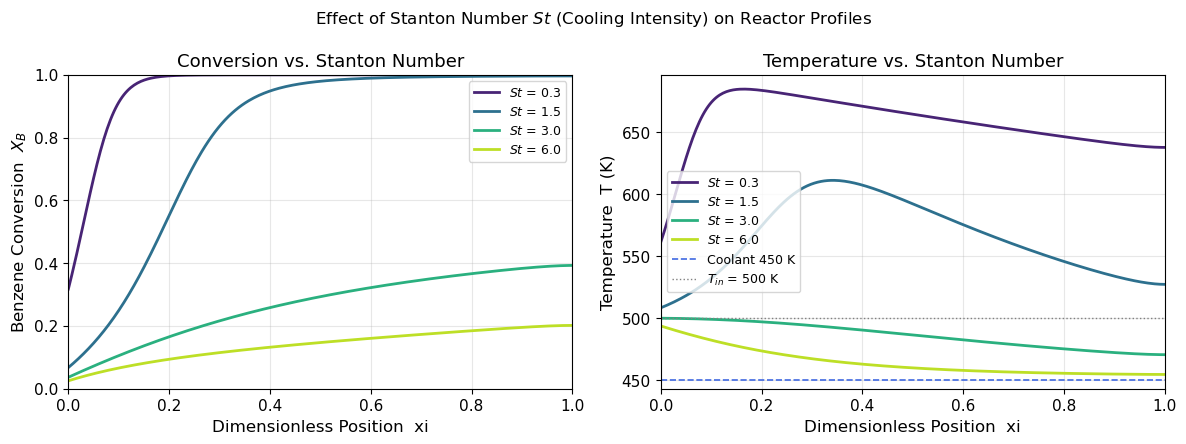

✓ 圖檔儲存：d:\MyGit\ChemE-3502\Unit09\outputs\Unit09_Example_04\figs\fig04_St_sensitivity.png


In [18]:
# ============================================================
# §6 Stanton 數系列求解
# ============================================================
# St 由小到大代表冷卻強度從接近絕熱到強制等溫
St_list   = [0.3, 1.5, 3.0, 6.0]
colors_st = plt.cm.viridis(np.linspace(0.1, 0.9, len(St_list)))

results_St = {}

for St_i, c in zip(St_list, colors_st):
    theta_pk = max(1.05, 1.0 + 0.4 / max(St_i, 0.3))

    def ode_st(xi, y):
        X_B_l = y[0];  dX_l = y[1]
        th_l  = y[2];  dt_l = y[3]
        th_s  = np.maximum(th_l, 0.3)
        r_l   = (1.0 - X_B_l) * np.exp(gamma * (1.0 - 1.0 / th_s))
        r_l   = np.where(X_B_l >= 1.0, 0.0, r_l)
        return np.array([
            dX_l,
            Pe_M * (dX_l - Da * r_l),
            dt_l,
            Pe_H * (dt_l - Da * beta_T * r_l + St_i * (th_l - theta_c))
        ])

    def bc_st(y_a, y_b):
        return np.array([
            y_a[0] - y_a[1] / Pe_M,
            y_b[1],
            y_a[2] - y_a[3] / Pe_H - 1.0,
            y_b[3]
        ])

    xi_g   = np.linspace(0, 1, 80)
    y_g    = make_init_guess(xi_g, X_exit=0.5, theta_peak=theta_pk)
    sol_st = solve_bvp(ode_st, bc_st, xi_g, y_g,
                       tol=1e-4, max_nodes=10000, verbose=0)
    if sol_st.success:
        y_st = sol_st.sol(xi_plot)
        results_St[St_i] = {'X': y_st[0], 'T': y_st[2] * T_in, 'color': c}
    else:
        print(f"  St={St_i:.1f}: 求解失敗 — {sol_st.message}")
        results_St[St_i] = None

# 摘要表格
print("各 Stanton 數求解結果：")
print(f"  {'St':>6} {'X_B(1)':>10} {'T_max (K)':>12} {'Hot Spot DeltaT (K)':>22}")
for St_i in St_list:
    if results_St[St_i] is not None:
        r = results_St[St_i]
        Xout = r['X'][-1];  Tmax = r['T'].max()
        print(f"  {St_i:>6.2f} {Xout:>10.4f} {Tmax:>12.1f} {Tmax - T_in:>22.1f}")

# ============================================================
# §6 圖04：不同 St 下的轉化率與溫度分布
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Effect of Stanton Number $St$ (Cooling Intensity) on Reactor Profiles",
             fontsize=12)

for St_i in St_list:
    if results_St[St_i] is None:
        continue
    r = results_St[St_i]
    lbl = f"$St$ = {St_i:.1f}"
    axes[0].plot(xi_plot, r['X'], color=r['color'], lw=2.0, label=lbl)
    axes[1].plot(xi_plot, r['T'], color=r['color'], lw=2.0, label=lbl)

axes[0].set_xlabel("Dimensionless Position  xi");  axes[0].set_xlim(0, 1)
axes[0].set_ylabel("Benzene Conversion  $X_B$");   axes[0].set_ylim(0, 1)
axes[0].set_title("Conversion vs. Stanton Number")
axes[0].legend(fontsize=9)

axes[1].axhline(T_c,  color='royalblue', lw=1.2, ls='--', label=f'Coolant {T_c:.0f} K')
axes[1].axhline(T_in, color='gray',      lw=1.0, ls=':',  label=f'$T_{{in}}$ = {T_in:.0f} K')
axes[1].set_xlabel("Dimensionless Position  xi");  axes[1].set_xlim(0, 1)
axes[1].set_ylabel("Temperature  T (K)")
axes[1].set_title("Temperature vs. Stanton Number")
axes[1].legend(fontsize=9)

plt.tight_layout()
fp = FIG_DIR / 'fig04_St_sensitivity.png'
plt.savefig(fp, bbox_inches='tight', dpi=150)
plt.show()
print(f"\u2713 \u5716\u6a94\u5132\u5b58\uff1a{fp}")

---
### 7. 課程重點整理 <a id="7"></a>

#### BVP vs IVP 關鍵比較

| 特性 | IVP | BVP |
|------|-----|-----|
| 邊界條件位置 | 全部在同一端（起始點） | 分散於兩端 |
| 求解策略 | 直接積分（forward march） | 迭代求解（反覆射擊或配置法） |
| SciPy 工具 | `solve_ivp()` | `solve_bvp()` |
| 初始猜測 | 不需要 | **必須提供**（對收斂至關重要） |
| 多解風險 | 較低 | **較高**（初始猜測不同可能得到不同解） |

#### `scipy.integrate.solve_bvp()` 使用摘要

```python
sol = solve_bvp(fun,           # ODE 函式 f(x, y)，回傳 shape (n_eq, N_mesh)
                bc,            # 邊界條件函式 bc(y_a, y_b)，回傳 shape (n_eq,)
                x,             # 初始網格節點，shape (N_mesh,)
                y,             # 初始猜測值，shape (n_eq, N_mesh)
                tol=1e-3,      # 殘差容差（預設 1e-3）
                max_nodes=1000)  # 最大節點數（若需精確解，可增至 5000~10000）
# 檢查收斂
print(sol.success, sol.message)
print(sol.rms_residuals)       # 各子區間殘差
# 插值取任意位置值
y_dense = sol.sol(xi_fine)     # shape (n_eq, len(xi_fine))
```

#### Danckwerts 邊界條件物理意義

當軸向擴散存在（ $Pe < \infty$ ）時，Danckwerts BC 保持**質量/能量連續性**：

$$
\underbrace{u C_{A0}}_{\text{入口進料通量}} = \underbrace{u C_A(0)}_{\text{對流通量}} - \underbrace{D_e \frac{dC_A}{dz}\bigg|_0}_{\text{軸向擴散通量}}
$$

換算為轉化率形式（無因次）：

$$
X_B(0) = \frac{1}{Pe_M}\frac{dX_B}{d\xi}\bigg|_{\xi=0}, \qquad \theta(0) - 1 = \frac{1}{Pe_H}\frac{d\theta}{d\xi}\bigg|_{\xi=0}
$$

#### 本例數值結果摘要（基準案例 $T_{\text{in}}=500$ K， $St=1.5$ ）

- BVP 收斂：4 次迭代，391 個自適應節點，最大殘差 $9.66 \times 10^{-6}$
- 出口轉化率 $X_B(1) = 0.9965$ （近完全轉化）
- 熱點位置 $\xi^* = 0.34$ （管長前段 $z^* \approx 0.68$ m）
- 熱點溫升 $\Delta T_{\text{hot}} = +111.1$ K（611 K vs 入口 500 K）
- 熱點轉化率 $X^* = 0.90$ （90% 轉化率時到達最高溫）

#### 熱點工程意義

| 冷卻條件 | $St$ | $T_{\text{max}}$ | $\Delta T_{\text{hot}}$ | $X_B(1)$ | 工程判斷 |
|---------|------|---------------|----------------------|---------|--------|
| 近絕熱 | 0.3 | 685 K | +185 K | ~1.00 | 觸媒燒結風險高 |
| 適中冷卻 | 1.5 | 611 K | +111 K | 0.997 | 良好操作點 |
| 強冷卻 | 3.0 | 499.9 K | −0.1 K | 0.393 | 過冷導致轉化率急降 |
| 過度冷卻 | 6.0 | 494 K | −6 K | 0.202 | 幾乎無反應 |

> **BVP 求解是化工反應器模擬中的基礎工具**，
> 適用於固定床反應器、邊界層傳遞、擴散與反應等工程問題。
> 初始猜測值的品質直接決定數值解的收斂速度與正確性。
